# Laboratorio 6: Git Wars - SVMs

**Duración:** 2 horas  
**Formato:** Competencia por Pull Requests  
**Repositorio base:** https://github.com/JAlbertoAlonso/gitwars-svm

---

## Portada del equipo

**Integrantes:**
- Arano Bejarano Melisa Asharet
- Fonseca González Bruno
- Flores Morales Luis Enrique
- Villalón Pineda Luis Enrique

**Repositorio del equipo:**  
<https://github.com/usuario/codewars-svm>

**Fecha de entrega:**  
18/10/2025

# Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC

## Fase 1 - Implementación de hinge loss

### Código - Fase 1

In [ ]:
def hinge_loss(w, b, X, y, C):
    w = np.asarray(w, dtype=float).reshape(-1)
    b = float(b)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    assert X.shape[0] == y.shape[0], "X e y deben tener el mismo número de muestras"
    assert X.shape[1] == w.shape[0], "Dimensiones incompatibles entre X y w"

    margins = y * (X @ w + b)
    hinge = np.maximum(0.0, 1.0 - margins)
    L = 0.5 * np.dot(w, w) + C * np.sum(hinge)
    return float(L)

# probamos la funcion
data = pd.read_csv("./train_linear.csv")
w = np.array([0.5, -0.3])
b = 0.1
C = 1.0
X = data[['x1', 'x2']].values
y = data['y'].values


hinge_loss(w = w, b = b, X = X,y = y ,C = C )

57.25725354634313

### Análisis - Fase 1

### 1. ¿Qué penaliza el término $||w||^2$ y qué controla $C$?

Recordemos que el término $||w||^2$ penaliza la complejidad del modelo, donde un valor pequeño significa un un margen más grande, lo cual es bueno porque el modelo será más simple y generalizará mejor a nuevos datos.

Así, la letra $C$ controla el equilibrio, donde:

* C alta: Le da mucha importancia a clasificar cada punto correctamente. Esto puede hacer el margen muy estrecho y que el modelo se sobreajuste.

* C baja: Le da más importancia a tener un margen más ancho, aunque eso signifique clasificar incorrectamente algunos puntos del entrenamiento.

### 2. ¿Cuándo la parte hinge contribuye con 0 al costo?

Primero recordemos que la parte **hinge** es la que calcula el error de clasificación.

Contribuye con 0 al costo cuando un punto de datos cumple dos condiciones:
1.  Está clasificado correctamente.
2.  Se encuentra lejos de la frontera de decisión (fuera del margen).

### Bitácora de control de versiones — Fase 1

### Rama utilizada: **"fase1/dijkstra"**
### Commit: **"feat(fase1) Función hinge loss"**
### Pull Request: **https://github.com/JAlbertoAlonso/gitwars-svm/pull/11**
### Cambios:

Se siguió el flujo de trabajo estándar mediante fork y sincronización con el repositorio base, asegurando que el contenido de main estuviera actualizado antes de crear la nueva rama.
El proceso incluyó preparar los cambios, realizar commits descriptivos y subir la rama al fork para posteriormente abrir el Pull Request hacia el repositorio original.
Entre las principales dificultades se encontró la correcta sincronización entre el fork y el repositorio base (upstream), la cual se resolvió mediante los comandos git fetch y git merge --ff-only.

### Comandos ejecutados:
**Para actualizar nuestro repositorio**
- git checkout main
- git pull origin main
- git fetch upstream
- git merge --ff-only upstream/main

**Para crear y usar la rama**
- git branch fase1/dijkstra
- git checkout fase1/dijkstra

**Para subir los cambios y realizar el pull request**
- git status
- git add fase1_dijkstra.py
- git commit -m "feat(fase1) Función hinge loss"
- git push origin fase1/dijkstra

### Conclusion: 

Se implementó la función Hinge Loss, encargada de calcular el costo total del SVM combinando la penalización del margen con la regularización del vector de pesos.
Se validó su comportamiento sobre datos linealmente separables, el término  $||w||^2$ actúa como regularizador al penalizar la complejidad del modelo, mientras que el parámetro 
$C$ controla el equilibrio entre mantener un margen amplio y permitir ciertos errores de clasificación.  
Además, se observó que la pérdida *hinge* solo contribuye al costo cuando un punto está mal clasificado o se encuentra dentro del margen, validando el comportamiento teórico esperado del modelo.


## Fase 2 - Entrenamiento lineal

### Código - Fase 2

Epoch 000: L = 184.1761
Epoch 001: L = 168.6691
Epoch 002: L = 153.4763
Epoch 003: L = 138.5822
Epoch 004: L = 123.9891
Epoch 005: L = 109.8328
Epoch 006: L = 97.1211
Epoch 007: L = 86.1295
Epoch 008: L = 78.5680
Epoch 009: L = 72.4170
Epoch 010: L = 67.7255
Epoch 011: L = 63.9968
Epoch 012: L = 61.0251
Epoch 013: L = 58.6399
Epoch 014: L = 56.4260
Epoch 015: L = 54.4241
Epoch 016: L = 52.7577
Epoch 017: L = 51.2756
Epoch 018: L = 49.9257
Epoch 019: L = 48.7647
Epoch 020: L = 47.6853
Epoch 021: L = 46.7309
Epoch 022: L = 45.8809
Epoch 023: L = 45.1327
Epoch 024: L = 44.4770
Epoch 025: L = 43.9090
Epoch 026: L = 43.3862
Epoch 027: L = 42.9104
Epoch 028: L = 42.4721
Epoch 029: L = 42.0423
Epoch 030: L = 41.6221
Epoch 031: L = 41.2087
Epoch 032: L = 40.8341
Epoch 033: L = 40.4792
Epoch 034: L = 40.1879
Epoch 035: L = 39.9293
Epoch 036: L = 39.7239
Epoch 037: L = 39.4861
Epoch 038: L = 39.3207
Epoch 039: L = 39.1598
Epoch 040: L = 39.0020
Epoch 041: L = 38.8473
Epoch 042: L = 38.6945
Epoch

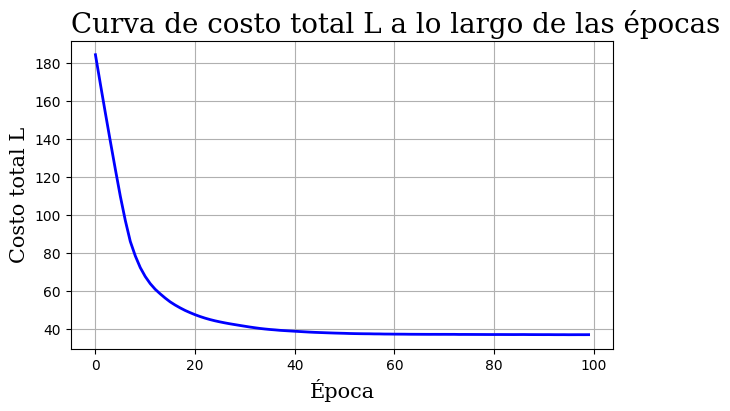

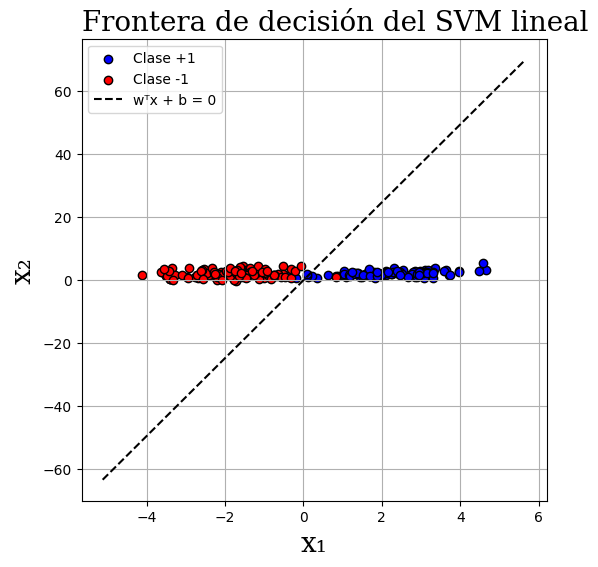

In [ ]:
def train_svm(X, y, C=1.0, eta=0.01, epochs=100, batch_size=1, seed=42):
    np.random.seed(seed)
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        X_shuf, y_shuf = X[idx], y[idx]

        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuf[start:end]
            y_batch = y_shuf[start:end]

            grad_w = np.zeros_like(w)
            grad_b = 0.0

            for x_i, y_i in zip(X_batch, y_batch):
                margin = y_i * (np.dot(w, x_i) + b)
                if margin >= 1:
                    grad_w += w
                    grad_b += 0
                else:
                    grad_w += w - C * y_i * x_i
                    grad_b += -C * y_i

            grad_w /= batch_size
            grad_b /= batch_size

            w -= eta * grad_w
            b -= eta * grad_b

        # Calcular L al final de cada época
        L = hinge_loss(w, b, X, y, C)
        losses.append(L)
        print(f"Epoch {epoch:03d}: L = {L:.4f}")

    return w, b, losses

# Predicción con datos linear e hiperparámetros
df = pd.read_csv("train_linear.csv")
X = df[['x1', 'x2']].values
y = df['y'].values
C = 1.0
eta = 0.001
epochs = 100

# Calculo de hinge loss para cada itreacion
w, b, losses = train_svm(X, y, C=C, eta=eta, epochs=epochs, batch_size=10)

# Reporte de accuracy final
y_pred = np.sign(X @ w + b)
accuracy = np.mean(y_pred == y)
print(f"\nAccuracy final: {accuracy*100:.2f}%")

# Grafica de pérdida
plt.figure(figsize=(7, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.title("Curva de costo total L a lo largo de las épocas", fontfamily='serif', fontsize=20, loc='left')
plt.xlabel("Época", fontfamily='serif', fontsize=15)
plt.ylabel("Costo total L", fontfamily='serif', fontsize=15)
plt.grid(True)
plt.show()

# Gráfica de frontera de desición
plt.figure(figsize=(6,6))
plt.scatter(X[y==1,0], X[y==1,1], c='b', label='Clase +1', edgecolor='k')
plt.scatter(X[y==-1,0], X[y==-1,1], c='r', label='Clase -1', edgecolor='k')

# Generamos la frontera wTx+b=0
x1_range = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_boundary = -(w[0]*x1_range + b) / w[1]
plt.plot(x1_range, x2_boundary, 'k--', label='wᵀx + b = 0')

plt.xlabel("x₁", fontfamily='serif', fontsize=20)
plt.ylabel("x₂", fontfamily='serif', fontsize=20)
plt.title("Frontera de decisión del SVM lineal", fontfamily='serif', fontsize=20, loc='left')
plt.legend()
plt.grid(True)
plt.show()

### Análisis - Fase 2

### 1. ¿Cómo afecta $C$ la cantidad de violaciones al margen?

El parámetro **$C$**  decide qué tan estricto es el modelo con los puntos que no respetan el marges.

* **Si $C$ es muy alta:** El modelo penaliza fuertemente cada error. Para evitar castigos, intentará clasificar casi todos los puntos correctamente, lo que resulta en muy pocas violaciones al margen. El riesgo es que el modelo se sobreajuste y cree una frontera de decisión muy compleja.

* **Si $C$ es muy baja:** El modelo es más tolerante con los errores. Prioriza tener un margen más ancho y simple, aunque eso signifique que más puntos violen el margen. Esto ayuda a que el modelo generalice mejor a datos nuevos.

### 2. ¿Qué ocurre si la tasa de aprendizaje es muy grande o muy pequeña?

* Si la tasa de aprendizaje es muy grande: Nunca converge y el error puede incluso aumentar.
    
* Si la tasa de aprendizaje es muy pequeña: El entrenamiento será extremadamente lento y podría quedarse atascado en una solución que no es la mejor (un mínimo local).


### Bitácora de control de versiones — Fase 2

### Rama utilizada: **"fase2/dijkstra"**
### Commit: **"feat(fase2): Linear train SVM"**
### Pull Request: **https://github.com/JAlbertoAlonso/gitwars-svm/pull/14**
### Cambios:


Igual que en la fase anterior se realizó la sincronización con el repositorio base, asegurando que el contenido de main estuviera actualizado antes de crear la nueva rama.
El proceso incluyó preparar los cambios, realizar commits descriptivos y subir la rama al fork para posteriormente abrir el Pull Request hacia el repositorio original.

### Comandos ejecutados:
**Para actualizar nuestro repositorio**
- git checkout main
- git pull origin main
- git fetch upstream
- git merge --ff-only upstream/main

**Para crear y usar la rama**
- git branch fase2/dijkstra
- git checkout fase2/dijkstra

**Para subir los cambios y realizar el pull request**
- git status
- git add fase2_dijkstra.py
- git commit -m "feat(fase2): Linear train SVM"
- git push origin fase2/dijkstra

### Conclusion

En esta fase se implementó el entrenamiento del **SVM lineal** mediante descenso por gradiente,actualizando los parámetros w y b con base en los gradientes del hinge loss. Se analizó la evolución del costo y la convergencia del modelo a través de las épocas.
Observando una **curva decreciente del costo total $L$**, lo que confirma que el algoritmo converge adecuadamente.  

El modelo alcanzó una **exactitud final del 97%**, indicando que logró una buena separación entre las clases.  
Verificamos que el parámetro $C$ influye directamente en la cantidad de fallos en el margen: valores altos reducen los errores pero pueden generar sobreajuste, mientras que valores bajos favorecen un margen más amplio y una mejor generalización.  

Veamos, la tasa de aprendizaje ($\eta$) demostró ser importante para la convergencia: una elección demasiado grande impide que el modelo estabilice el costo, y una demasiado pequeña ralentiza el aprendizaje.  
En conjunto, los resultados confirman el funcionamiento teórico del SVM y la correcta implementación del procedimiento de optimización.


## Fase 3 - Visualización y análisis del margen

### Código - Fase 3

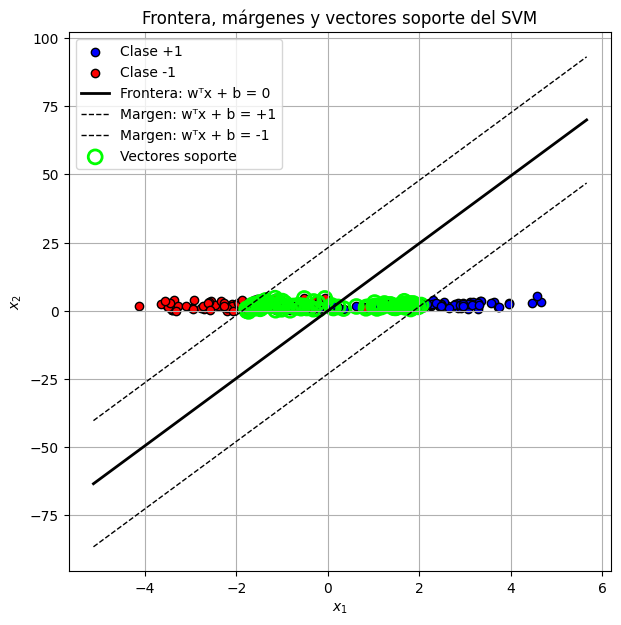

Número de vectores soporte: 95


"\nLos vectores soporte son los puntos donde y_i (wᵀx_i + b) ≤ 1.\n   Estos están sobre el margen o dentro del área de violación.\n\nEn el SVM lineal, solo estos puntos 'soportan' la solución\n   porque definen el margen óptimo: si los movemos, la frontera cambia.\n   Los puntos más alejados del margen no influyen en w ni en b.\n\nEl ancho del margen está dado por:\n      margen = 2 / ||w||\n   Por lo tanto, un ||w|| grande (pesos más grandes) implica un margen más angosto,\n   mientras que un ||w|| pequeño produce un margen más ancho.\n"

In [ ]:
# Vectores soporte
margins = y * (X @ w + b)
support_idx = np.where(margins <= 1 + 1e-6)[0]
support_vectors = X[support_idx]

plt.figure(figsize=(7,7))

plt.scatter(X[y==1,0], X[y==1,1], c='blue', label='Clase +1', edgecolor='k')
plt.scatter(X[y==-1,0], X[y==-1,1], c='red', label='Clase -1', edgecolor='k')

# Frontera y márgenes
x1_range = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
x2_decision = -(w[0]*x1_range + b)/w[1]
x2_margin_pos = -(w[0]*x1_range + b - 1)/w[1]
x2_margin_neg = -(w[0]*x1_range + b + 1)/w[1]

plt.plot(x1_range, x2_decision, 'k-', linewidth=2, label='Frontera: wᵀx + b = 0')
plt.plot(x1_range, x2_margin_pos, 'k--', linewidth=1, label='Margen: wᵀx + b = +1')
plt.plot(x1_range, x2_margin_neg, 'k--', linewidth=1, label='Margen: wᵀx + b = -1')

# Vectores soporte
plt.scatter(support_vectors[:,0], support_vectors[:,1],
            s=100, facecolors='none', edgecolors='lime', linewidths=2, label='Vectores soporte')

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Frontera, márgenes y vectores soporte del SVM")
plt.legend()
plt.grid(True)
plt.show()


print("Número de vectores soporte:", len(support_vectors))

Los vectores soporte son los puntos donde $y_i (wᵀx_i + b) ≤ 1$.
   Estos están sobre el margen o dentro del área de violación.

En el SVM lineal, solo estos puntos 'soportan' la solución
   porque definen el margen óptimo: si los movemos, la frontera cambia.
   Los puntos más alejados del margen no influyen en w ni en b.

El ancho del margen está dado por:
      margen = $2/||w||$
   Por lo tanto, un $||w||$ grande (pesos más grandes) implica un margen más angosto,
   mientras que un ||w|| pequeño produce un margen más ancho.


### Análisis - Fase 3

### 1. ¿Qué relación hay entre el ancho del margen y $\|w\|$?

La relación es inversamente proporcional:

- El vector $w$ define la "inclinación" o pendiente de la frontera que separa las clases, por lo que el término $\|w\|$ es la norma de ese vector, así el ancho del margen es igual a $2/\|w\|$. Por lo tanto:

-   Si $\|w\|$ es pequeño, el denominador es pequeño, lo que resulta en un margen más ancho.
-   Si $\|w\|$ es grande, el denominador es grande, lo que resulta en un margen más estrecho.

### 2. ¿Por qué modificar $b$ desplaza la frontera sin cambiar su orientación?

La frontera de decisión se define por la ecuación: $$w \cdot x + b = 0$$

* El vector $w$ define la orientación.  Este vector es perpendicular a la línea o plano de la frontera. Si cambias $w$, la frontera rota.

- El término $b$ define la posición. Es un número escalar que se suma al resultado. Cambiar $b$ simplemente desplaza la frontera a lo largo del eje definido por $w$, sin alterar su ángulo.

### Bitácora de control de versiones — Fase 3

### Rama utilizada: **"fase3/dijkstra"**
### Commit: **"feat(fase3):Visualización y análisis del margen"**
### Pull Request: **https://github.com/JAlbertoAlonso/gitwars-svm/pull/17**
### Cambios:


Igual que en la fase anterior se realizó la sincronización con el repositorio base, asegurando que el contenido de main estuviera actualizado antes de crear la nueva rama.
El proceso incluyó preparar los cambios, realizar commits descriptivos y subir la rama al fork para posteriormente abrir el Pull Request hacia el repositorio original.

### Comandos ejecutados:
**Para actualizar nuestro repositorio**
- git checkout main
- git pull origin main
- git fetch upstream
- git merge --ff-only upstream/main

**Para crear y usar la rama**
- git branch fase3/dijkstra
- git checkout fase3/dijkstra

**Para subir los cambios y realizar el pull request**
- git status
- git add fase3_dijkstra.py
- git commit -m "feat(fase3):Visualización y análisis del margen"
- git push origin fase3/dijkstra

###  Conclusión 

En esta fase se identificaron los **vectores soporte**, es decir, los puntos que cumplen $y_i (wᵀx_i + b) \le 1$ y que definen directamente la frontera y el margen óptimo del SVM.  
Se observó que solo estos puntos determinan la solución final, ya que moverlos modifica el valor de $w$ y $b$, mientras que los puntos alejados del margen no influyen en la frontera de decisión.

Además, se comprobó que el **ancho del margen** es inversamente proporcional a la norma del vector de pesos, mediante la visualizacion de la frontera de decisión junto con los márgenes y se estudió la relación entre el tamaño del vector w y el ancho del margen.:

$$\text{margen} = \frac{2}{||w||}$$

Por lo tanto, un $||w||$ grande genera un margen más estrecho y uno pequeño produce un margen más amplio.  
También se verificó que modificar $b$ únicamente **desplaza la frontera de decisión** sin alterar su orientación, confirmando el comportamiento teórico esperado del modelo SVM.


## Fase 4 - Idea dual + Kernel RBF

### Código - Fase 4

Accuracy (train): 99.50%
Número de vectores soporte: 52


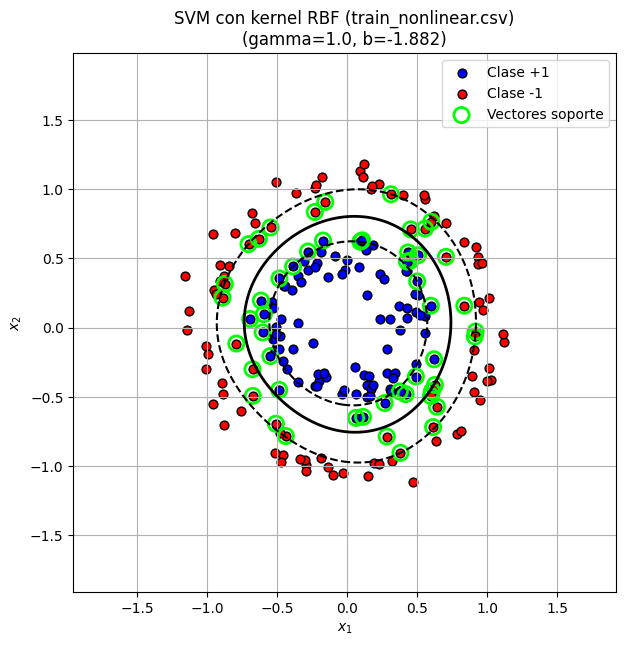

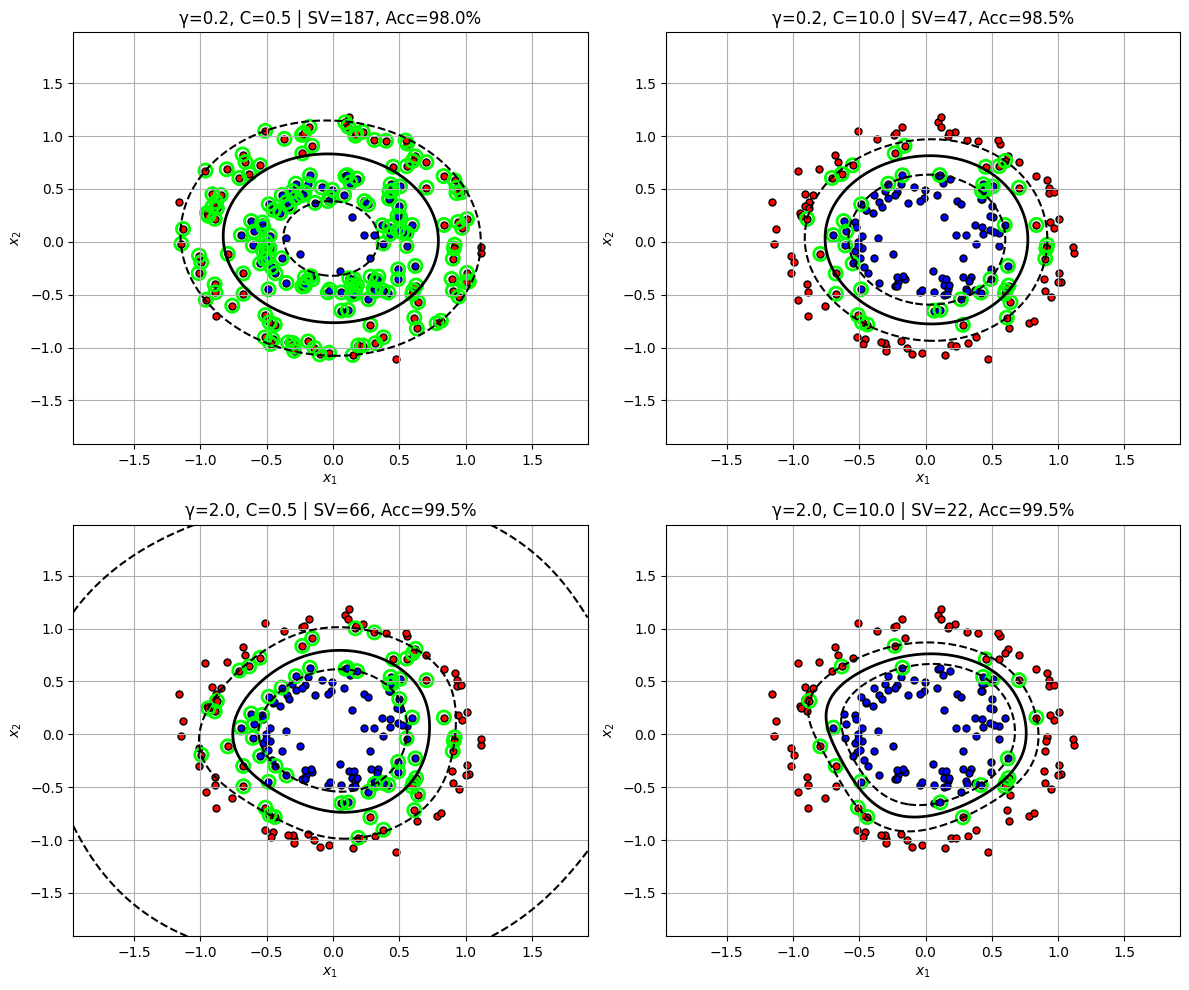

In [ ]:
def rbf_kernel(X, Z, gamma):
    """
    K(x,z) = exp(-gamma * ||x - z||^2)
    X: (n, d), Z: (m, d)
    return: (n, m)
    """
    X2 = np.sum(X**2, axis=1)[:, None]
    Z2 = np.sum(Z**2, axis=1)[None, :]
    dists2 = X2 + Z2 - 2 * X @ Z.T
    return np.exp(-gamma * dists2)

def gram_matrix(X, gamma):
    return rbf_kernel(X, X, gamma)

def train_rbf_svm(X, y, C=1.0, gamma=1.0):
    """
    Entrena SVC(kernel='rbf') y devuelve:
    - w (no existe explícitamente en RBF; devolvemos None)
    - b (intercept_)
    - support_vectors (SVs)
    - support_idx (índices de SVs)
    - alphas (solo para los SVs)
    - dual_coef (vector con y_i * alpha_i para SVs)
    - clf (modelo entrenado)
    """
    clf = SVC(kernel='rbf', C=C, gamma=gamma)
    clf.fit(X, y)


    support_idx = clf.support_
    support_vectors = clf.support_vectors_
    dual_coef = clf.dual_coef_[0]            # y_sv * alpha_sv
    y_sv = y[support_idx]
    alphas = np.abs(dual_coef)               # alpha_sv >= 0
    b = float(clf.intercept_[0])

    eps = 1e-8
    margin_mask = (alphas > eps) & (alphas < C - eps)
    if np.any(margin_mask):
        K_sv = rbf_kernel(support_vectors, support_vectors[margin_mask], gamma)
        b_est = y_sv[margin_mask] - (dual_coef @ K_sv)
        b = float(np.mean(b_est))

    return None, b, support_vectors, support_idx, alphas, dual_coef, clf

def decision_function(X_new, support_vectors, y_sv, dual_coef, b, gamma):
    K = rbf_kernel(X_new, support_vectors, gamma)
    return K @ dual_coef + b

def plot_decision_boundary_rbf(X, y, support_vectors, y_sv, dual_coef, b, gamma,
                               title="SVM RBF: frontera, márgenes y SVs",
                               s=40, cmap_points=None):
    if cmap_points is None:
        # Colores simples: azul para +1, rojo para -1
        cmap_points = {1: 'blue', -1: 'red'}

    pad = 0.8
    x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
    y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    Xgrid = np.c_[xx.ravel(), yy.ravel()]

    fvals = decision_function(Xgrid, support_vectors, y_sv, dual_coef, b, gamma)
    fvals = fvals.reshape(xx.shape)

    plt.figure(figsize=(7,7))
    plt.contour(xx, yy, fvals, levels=[0], linewidths=2, linestyles='-', colors='k')
    plt.contour(xx, yy, fvals, levels=[-1, 1], linewidths=1.5, linestyles='--', colors='k')

    plt.scatter(X[y==1,0], X[y==1,1], c=cmap_points[1], s=s, edgecolor='k', label='Clase +1')
    plt.scatter(X[y==-1,0], X[y==-1,1], c=cmap_points[-1], s=s, edgecolor='k', label='Clase -1')

    plt.scatter(support_vectors[:,0], support_vectors[:,1],
                s=120, facecolors='none', edgecolors='lime', linewidths=2, label='Vectores soporte')

    plt.title(title + f"\n(gamma={gamma}, b={b:.3f})")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.grid(True)
    plt.show()

df = pd.read_csv("train_nonlinear.csv")
X = df[['x1', 'x2']].values
y = df['y'].values.astype(int)

C = 1.0
gamma = 1.0
_, b, SV, sv_idx, alphas_sv, dual_coef, clf = train_rbf_svm(X, y, C=C, gamma=gamma)

y_sv = y[sv_idx]

y_pred = clf.predict(X)
acc = (y_pred == y).mean()
print(f"Accuracy (train): {acc*100:.2f}%")
print(f"Número de vectores soporte: {SV.shape[0]}")

plot_decision_boundary_rbf(X, y, SV, y_sv, dual_coef, b, gamma,
                           title="SVM con kernel RBF (train_nonlinear.csv)")

configs = [
    (0.2, 0.5),
    (0.2, 10.0),
    (2.0, 0.5),
    (2.0, 10.0),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (g, c) in zip(axes, configs):
    _, b_i, SV_i, sv_idx_i, alphas_i, dc_i, clf_i = train_rbf_svm(X, y, C=c, gamma=g)
    y_sv_i = y[sv_idx_i]
    # Malla
    pad = 0.8
    x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
    y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Xgrid = np.c_[xx.ravel(), yy.ravel()]
    fvals = decision_function(Xgrid, SV_i, y_sv_i, dc_i, b_i, g).reshape(xx.shape)

    # Contornos
    cs0 = ax.contour(xx, yy, fvals, levels=[0], linewidths=2, linestyles='-', colors='k')
    cs1 = ax.contour(xx, yy, fvals, levels=[-1, 1], linewidths=1.5, linestyles='--', colors='k')

    # Puntos y SV
    ax.scatter(X[y==1,0], X[y==1,1], c='blue', s=25, edgecolor='k')
    ax.scatter(X[y==-1,0], X[y==-1,1], c='red',  s=25, edgecolor='k')
    ax.scatter(SV_i[:,0], SV_i[:,1], s=90, facecolors='none', edgecolors='lime', linewidths=2)

    acc_i = (clf_i.predict(X) == y).mean()
    ax.set_title(f"γ={g}, C={c} | SV={SV_i.shape[0]}, Acc={acc_i*100:.1f}%")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Análisis - Fase 4

### 1. ¿Qué sucede al aumentar $\gamma$ en la suavidad de la frontera?

Al aumentar $\gamma$, la frontera de decisión se vuelve menos suave y más compleja.

-   $\gamma$ baja: es una frontera suave y general.
-   $\gamma$ alta: es una frontera irregular y ajustada.

### 2. ¿Cómo interactúan $C$ y $\gamma$ en el sobreajuste o subajuste?

-   Sobreajuste:  Ocurre con $C$ alta y $\gamma$ alta, el modelo se vuelve demasiado estricto y usa una frontera demasiado compleja para memorizar los datos de entrenamiento.

-   Subajuste (Underfitting): Ocurre con $C$ baja y $\gamma$ baja, el modelo es demasiado tolerante a errores y su frontera es demasiado simple, por lo que no aprende bien la estructura de los datos.

### Bitácora de control de versiones — Fase 4

### Rama utilizada: **"fase4/dijkstra"**
### Commit: **"feat(fase4):Ideal Dual + Kernel RBF"**
### Pull Request: **https://github.com/JAlbertoAlonso/gitwars-svm/pull/20**
### Cambios:

Igual que en la fase anterior se realizó la sincronización con el repositorio base, asegurando que el contenido de main estuviera actualizado antes de crear la nueva rama.
El proceso incluyó preparar los cambios, realizar commits descriptivos y subir la rama al fork para posteriormente abrir el Pull Request hacia el repositorio original.

### Comandos ejecutados:
**Para actualizar nuestro repositorio**
- git checkout main
- git pull origin main
- git fetch upstream
- git merge --ff-only upstream/main

**Para crear y usar la rama**
- git branch fase4/dijkstra
- git checkout fase4/dijkstra

**Para subir los cambios y realizar el pull request**
- git status
- git add fase4_dijkstra.py
- git commit -m "feat(fase4):Ideal Dual + Kernel RBF"
- git push origin fase4/dijkstra

###  Conclusión 

En esta fase se implementó el **SVM con kernel RBF (Radial Basis Function)** para clasificar datos no linealmente separables.  
Se observó que el modelo logra una **exactitud de 99.5%** con un número moderado de vectores soporte, demostrando la capacidad del kernel para proyectar los datos a un espacio de mayor dimensión donde la separación es lineal.

Al analizar los parámetros, se vio que el valor de **$\gamma$** controla la **suavidad de la frontera**:  
- Un $\gamma$ bajo produce una frontera amplia y suave (modelo más general).  
- Un $\gamma$ alto genera una frontera más ajustada y compleja (riesgo de sobreajuste).  

Por otro lado, el parámetro **$C$** regula la **penalización de errores**:  
- Valores altos de $C$ hacen que el modelo sea más estricto con los errores (mayor ajuste a los datos de entrenamiento).  
- Valores bajos permiten más flexibilidad (mejor generalización).

En conjunto, la interacción entre $C$ y $\gamma$ define el equilibrio entre **sobreajuste y subajuste**, confirmando el comportamiento teórico del SVM con kernel RBF en problemas no lineales.


## Conclusiones finales

A lo largo de esta práctica se implementaron y analizaron paso a paso los fundamentos del **Máquina de Vectores de Soporte (SVM)**, desde su versión lineal hasta su extensión con **kernel RBF** para casos no lineales.

En la **Fase 1**, se comprendió la función de costo del SVM basada en la **hinge loss**, observando cómo el término $||w||^2$ regula la complejidad del modelo y el parámetro $C$ controla el equilibrio entre el margen y las penalizaciones por error.

En la **Fase 2**, se entrenó el SVM mediante **descenso por gradiente**, verificando la convergencia del costo total $L$ y obteniendo una alta precisión, lo que permitió visualizar la frontera de decisión lineal y analizar el efecto de los hiperparámetros $C$ y $\eta$.

En la **Fase 3**, se identificaron los **vectores soporte**, confirmando que solo estos puntos determinan la posición del margen y que el ancho del mismo es inversamente proporcional a la norma del vector de pesos $||w||$. Además, se comprendió que el término $b$ únicamente desplaza la frontera sin modificar su orientación.

Finalmente, en la **Fase 4**, se implementó el **SVM con kernel RBF**, extendiendo el modelo a problemas no linealmente separables. Se comprobó cómo los parámetros $C$ y $\gamma$ influyen directamente en la suavidad y complejidad de la frontera, permitiendo equilibrar entre **generalización y sobreajuste**.

Todo esto nos permitio permitió entender mejor los conceptos teóricos con su aplicación computacional, comprendiendo el funcionamiento interno del SVM, su proceso de optimización y el impacto de los hiperparámetros en la calidad del modelo.
